<a href="https://colab.research.google.com/github/RishithSuresh/Used-Car-Resale-Price-Data-Preprocessing-Pipeline/blob/master/mainfile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [29]:
df = pd.read_csv("used_car_resale_dataset.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (320, 15)


,Car_ID,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,CAR0001,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,CAR0002,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,CAR0003,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,CAR0004,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,CAR0005,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              320 non-null    object 
 1   Brand               320 non-null    object 
 2   Year                320 non-null    int64  
 3   Mileage_Km          320 non-null    int64  
 4   Engine_CC           320 non-null    int64  
 5   Power_BHP           320 non-null    float64
 6   Fuel_Type           320 non-null    object 
 7   Transmission        320 non-null    object 
 8   City                320 non-null    object 
 9   Seller_Type         320 non-null    object 
 10  Condition           320 non-null    object 
 11  Previous_Owners     320 non-null    int64  
 12  Accidents_Reported  320 non-null    int64  
 13  Service_Score       320 non-null    int64  
 14  Resale_Price_Lakh   320 non-null    float64
dtypes: float64(2), int64(6), object(7)
memory usage: 37.6+ KB

In [31]:
df.describe()

,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2019.537500,74110.203125,1346.703125,150.489688,1.668750,0.243750,76.203125,4.963031
std,3.341367,38885.260771,543.408160,36.665353,0.865369,0.528164,12.745864,3.359259
min,2014.000000,700.000000,600.000000,51.400000,1.000000,0.000000,55.000000,1.200000
25%,2017.000000,46323.250000,1004.750000,128.450000,1.000000,0.000000,64.750000,2.277500
50%,2020.000000,72718.500000,1303.000000,150.750000,1.000000,0.000000,77.000000,4.610000
75%,2022.000000,97951.500000,1635.250000,171.475000,2.000000,0.000000,87.000000,6.835000
max,2025.000000,320000.000000,5000.000000,390.000000,4.000000,2.000000,98.000000,28.500000


In [32]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Car_ID                0
Brand                 0
Year                  0
Mileage_Km            0
Engine_CC             0
Power_BHP             0
Fuel_Type             0
Transmission          0
City                  0
Seller_Type           0
Condition             0
Previous_Owners       0
Accidents_Reported    0
Service_Score         0
Resale_Price_Lakh     0
dtype: int64


In [33]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
Car_ID                0.0
Brand                 0.0
Year                  0.0
Mileage_Km            0.0
Engine_CC             0.0
Power_BHP             0.0
Fuel_Type             0.0
Transmission          0.0
City                  0.0
Seller_Type           0.0
Condition             0.0
Previous_Owners       0.0
Accidents_Reported    0.0
Service_Score         0.0
Resale_Price_Lakh     0.0
dtype: float64


In [34]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [35]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (320, 15)


In [36]:
categorical_columns = [
    "Brand",
    "Fuel_Type",
    "Transmission",
    "City",
    "Seller_Type",
    "Condition"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Brand:
Brand
Volkswagen    39
Toyota        37
Renault       36
Skoda         33
Honda         33
Mahindra      31
Hyundai       31
Tata          28
Maruti        27
Kia           25
Name: count, dtype: int64

Fuel_Type:
Fuel_Type
Petrol      182
Diesel       97
CNG          21
Electric     20
Name: count, dtype: int64

Transmission:
Transmission
Manual       197
Automatic    123
Name: count, dtype: int64

City:
City
Lucknow       43
Bengaluru     39
Delhi         37
Ahmedabad     36
Hyderabad     36
Chandigarh    29
Jaipur        28
Pune          26
Kochi         24
Mumbai        22
Name: count, dtype: int64

Seller_Type:
Seller_Type
Individual          167
Dealer              100
Certified Dealer     53
Name: count, dtype: int64

Condition:
Condition
Good         138
Very Good     96
Excellent     37
Fair          34
Poor          15
Name: count, dtype: int64


In [37]:
print(df["Condition"].unique())

['Good' 'Very Good' 'Excellent' 'Fair' 'Poor']


In [38]:
X = df.drop(columns=["Resale_Price_Lakh"])
y = df["Resale_Price_Lakh"]

In [39]:
X = X.drop(columns=["Car_ID"])

In [40]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Brand', 'Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Fuel_Type', 'Transmission', 'City', 'Seller_Type', 'Condition', 'Previous_Owners', 'Accidents_Reported', 'Service_Score']

Target:
Resale_Price_Lakh


In [41]:
numerical_features = [
    "Year",
    "Mileage_Km",
    "Engine_CC",
    "Power_BHP",
    "Previous_Owners",
    "Accidents_Reported",
    "Service_Score"
]

In [42]:
nominal_features = [
    "Brand",
    "Fuel_Type",
    "Transmission",
    "City",
    "Seller_Type"
]

In [43]:
ordinal_features = [
    "Condition"
]

In [44]:
def iqr_outlier_summary(data, columns):

    results = []

    for column in columns:

        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[
            (data[column] < lower_bound) |
            (data[column] > upper_bound)
        ]

        results.append({
            "Column": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": len(outliers)
        })

    return pd.DataFrame(results)

In [45]:
outlier_summary = iqr_outlier_summary(
    X,
    numerical_features
)

display(outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Year,2017.00,2022.000,5.000,2009.5000,2029.5000,0
1,Mileage_Km,46323.25,97951.500,51628.250,-31119.1250,175393.8750,2
2,Engine_CC,1004.75,1635.250,630.500,59.0000,2581.0000,6
3,Power_BHP,128.45,171.475,43.025,63.9125,236.0125,7
4,Previous_Owners,1.00,2.000,1.000,-0.5000,3.5000,14
5,Accidents_Reported,0.00,0.000,0.000,0.0000,0.0000,63
6,Service_Score,64.75,87.000,22.250,31.3750,120.3750,0


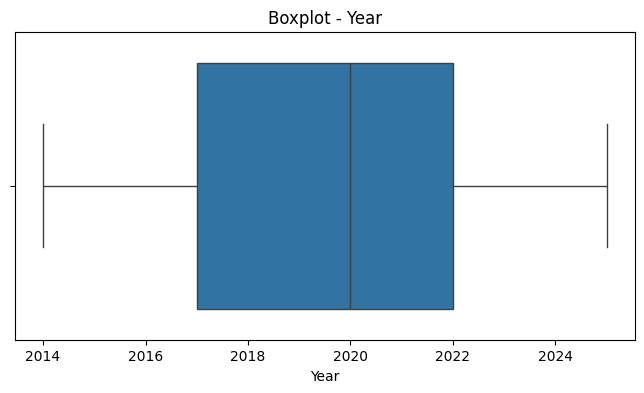

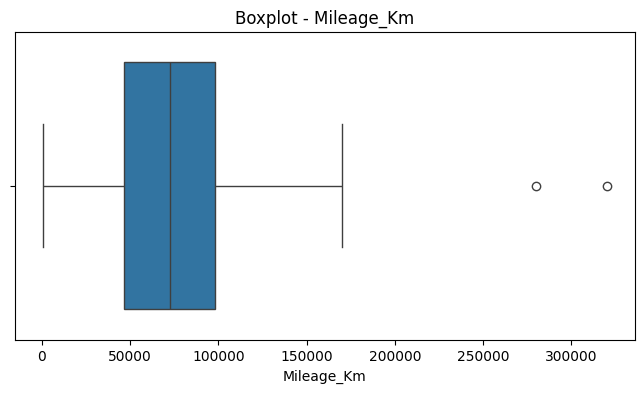

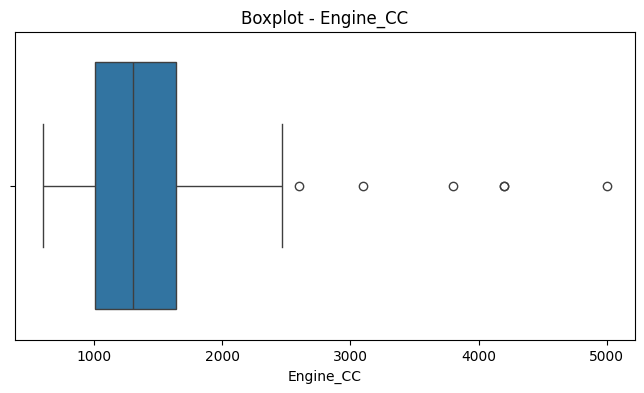

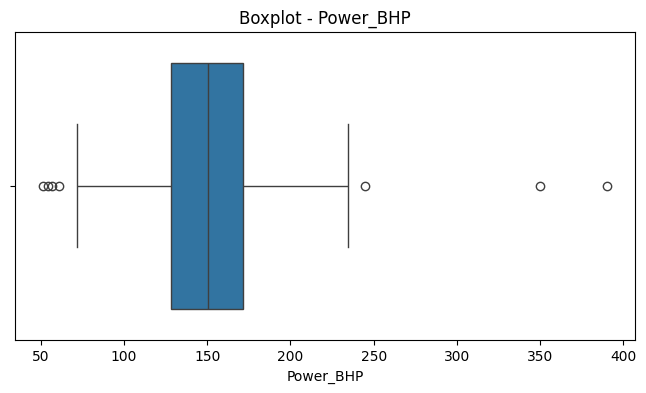

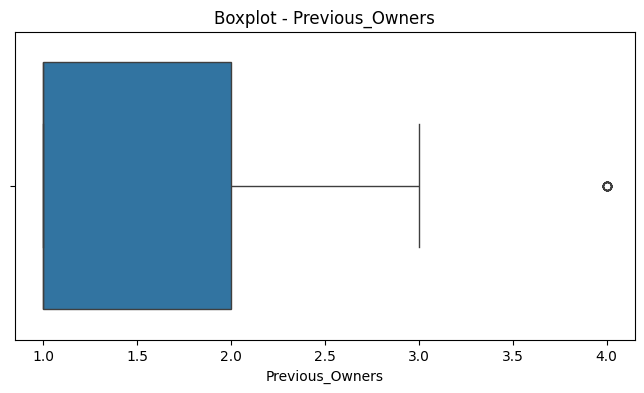

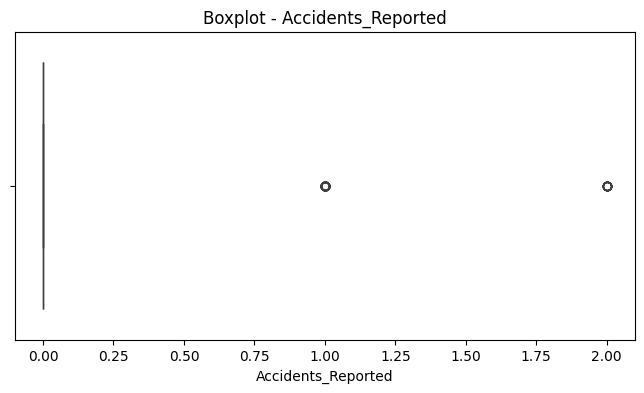

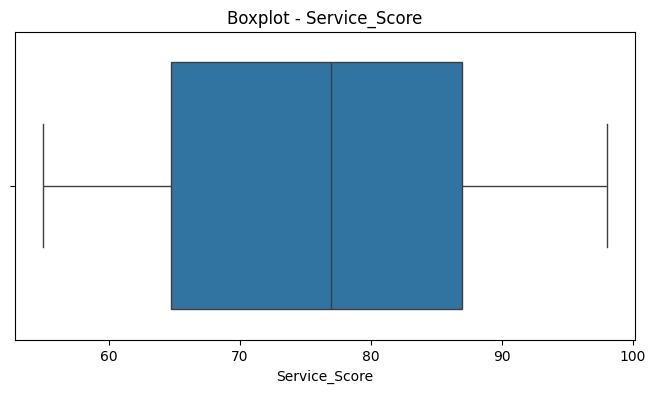

In [46]:
for column in numerical_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot - {column}")
    plt.xlabel(column)

    plt.show()

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [48]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (256, 13)
Testing set: (64, 13)


In [49]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [50]:
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [51]:
ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    [
                        "Poor",
                        "Fair",
                        "Average",
                        "Good",
                        "Very Good",
                        "Excellent"
                    ]
                ]
            )
        )
    ]
)

In [52]:
categories=[
    ["Bad", "Fair", "Good", "Very Good", "Excellent"]
]

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "nominal",
            nominal_pipeline,
            nominal_features
        ),
        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features
        )
    ]
)

In [54]:
X_train_processed = preprocessor.fit_transform(X_train)

In [55]:
X_test_processed = preprocessor.transform(X_test)

In [56]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed Features:")
for feature in feature_names:
    print(feature)

Number of processed features: 37

Processed Features:
numerical__Year
numerical__Mileage_Km
numerical__Engine_CC
numerical__Power_BHP
numerical__Previous_Owners
numerical__Accidents_Reported
numerical__Service_Score
nominal__Brand_Honda
nominal__Brand_Hyundai
nominal__Brand_Kia
nominal__Brand_Mahindra
nominal__Brand_Maruti
nominal__Brand_Renault
nominal__Brand_Skoda
nominal__Brand_Tata
nominal__Brand_Toyota
nominal__Brand_Volkswagen
nominal__Fuel_Type_CNG
nominal__Fuel_Type_Diesel
nominal__Fuel_Type_Electric
nominal__Fuel_Type_Petrol
nominal__Transmission_Automatic
nominal__Transmission_Manual
nominal__City_Ahmedabad
nominal__City_Bengaluru
nominal__City_Chandigarh
nominal__City_Delhi
nominal__City_Hyderabad
nominal__City_Jaipur
nominal__City_Kochi
nominal__City_Lucknow
nominal__City_Mumbai
nominal__City_Pune
nominal__Seller_Type_Certified Dealer
nominal__Seller_Type_Dealer
nominal__Seller_Type_Individual
ordinal__Condition


In [57]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [58]:
display(X_train_processed_df.head())

,numerical__Year,numerical__Mileage_Km,numerical__Engine_CC,numerical__Power_BHP,numerical__Previous_Owners,numerical__Accidents_Reported,numerical__Service_Score,nominal__Brand_Honda,nominal__Brand_Hyundai,nominal__Brand_Kia,...,nominal__City_Hyderabad,nominal__City_Jaipur,nominal__City_Kochi,nominal__City_Lucknow,nominal__City_Mumbai,nominal__City_Pune,nominal__Seller_Type_Certified Dealer,nominal__Seller_Type_Dealer,nominal__Seller_Type_Individual,ordinal__Condition
132,-0.486391,-0.226001,-0.305874,0.236430,-0.734379,-0.442634,-0.454105,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0
317,0.725445,0.055103,-0.569724,-0.312374,-0.734379,1.477948,-0.614672,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
234,-1.395268,0.970340,-0.145805,0.336953,-0.734379,-0.442634,-0.534389,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0
312,1.028404,-0.198531,0.329125,0.331520,0.433329,-0.442634,0.188165,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0
232,-1.092309,0.605540,0.571867,-0.404747,0.433329,-0.442634,0.107881,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0


In [59]:
print(
    "Training missing values:",
    X_train_processed_df.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_processed_df.isnull().sum().sum()
)

Training missing values: 0
Testing missing values: 0


In [60]:
X_train_processed_df[
    [column for column in X_train_processed_df.columns
     if column.startswith("numerical__")]
].describe()

,numerical__Year,numerical__Mileage_Km,numerical__Engine_CC,numerical__Power_BHP,numerical__Previous_Owners,numerical__Accidents_Reported,numerical__Service_Score
count,2.560000e+02,2.560000e+02,2.560000e+02,2.560000e+02,2.560000e+02,2.560000e+02,2.560000e+02
mean,-3.816392e-17,-6.938894e-18,2.428613e-17,1.734723e-17,-6.938894e-18,3.816392e-17,-6.938894e-18
std,1.001959e+00,1.001959e+00,1.001959e+00,1.001959e+00,1.001959e+00,1.001959e+00,1.001959e+00
min,-1.698227e+00,-1.849768e+00,-1.340165e+00,-2.708637e+00,-7.343793e-01,-4.426342e-01,-1.738645e+00
25%,-7.893502e-01,-7.112221e-01,-6.132588e-01,-5.820217e-01,-7.343793e-01,-4.426342e-01,-8.755947e-01
50%,1.195268e-01,-3.384801e-02,-9.479359e-02,-1.623743e-02,-7.343793e-01,-4.426342e-01,1.078813e-01
75%,7.254448e-01,5.896819e-01,4.975496e-01,5.447924e-01,4.333294e-01,-4.426342e-01,7.501513e-01
max,1.634322e+00,6.192202e+00,6.399433e+00,6.490621e+00,2.768747e+00,3.398530e+00,1.713556e+00


In [61]:
condition_column = [
    column
    for column in X_train_processed_df.columns
    if "ordinal__Condition" in column
]

print(condition_column)

display(
    X_train_processed_df[condition_column].head()
)

['ordinal__Condition']


,ordinal__Condition
132,4.0
317,3.0
234,3.0
312,3.0
232,4.0


In [62]:
train_processed = X_train_processed_df.copy()
train_processed["Resale_Price_Lakh"] = y_train

test_processed = X_test_processed_df.copy()
test_processed["Resale_Price_Lakh"] = y_test

In [63]:
display(train_processed.head())

,numerical__Year,numerical__Mileage_Km,numerical__Engine_CC,numerical__Power_BHP,numerical__Previous_Owners,numerical__Accidents_Reported,numerical__Service_Score,nominal__Brand_Honda,nominal__Brand_Hyundai,nominal__Brand_Kia,...,nominal__City_Jaipur,nominal__City_Kochi,nominal__City_Lucknow,nominal__City_Mumbai,nominal__City_Pune,nominal__Seller_Type_Certified Dealer,nominal__Seller_Type_Dealer,nominal__Seller_Type_Individual,ordinal__Condition,Resale_Price_Lakh
132,-0.486391,-0.226001,-0.305874,0.236430,-0.734379,-0.442634,-0.454105,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,4.26
317,0.725445,0.055103,-0.569724,-0.312374,-0.734379,1.477948,-0.614672,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,5.30
234,-1.395268,0.970340,-0.145805,0.336953,-0.734379,-0.442634,-0.534389,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.23
312,1.028404,-0.198531,0.329125,0.331520,0.433329,-0.442634,0.188165,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,7.09
232,-1.092309,0.605540,0.571867,-0.404747,0.433329,-0.442634,0.107881,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.69


In [64]:
train_processed.to_csv(
    "used_car_train_preprocessed.csv",
    index=False
)

test_processed.to_csv(
    "used_car_test_preprocessed.csv",
    index=False
)